# 🔍 Hate Speech Detection — Pipeline ML Complet
**Dataset** : `HateSpeechData.csv` · 24 783 tweets · 3 classes  
**Approche** : ML  | TF-IDF (word + char) · FastText · Confidence-based filtering .  Weighted sampling 



## 1 · Imports & Configuration

In [1]:
!pip install wordcloud

In [2]:
import os, re, warnings, time
import numpy  as np
import pandas as pd

!pip install gensim
# ── NLP ──────────────────────────────────────────────────────────────
import nltk
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from gensim.models import FastText as FastTextModel

# ── Sklearn — features ───────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing           import LabelEncoder
from sklearn.pipeline                import Pipeline
from sklearn.base                    import BaseEstimator, TransformerMixin
import scipy.sparse as sp

# ── Sklearn — modèles ────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression, SGDClassifier
from sklearn.svm           import LinearSVC
from sklearn.naive_bayes   import ComplementNB
from sklearn.ensemble      import VotingClassifier
from sklearn.calibration   import CalibratedClassifierCV

# ── Sklearn — évaluation ─────────────────────────────────────────────
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      train_test_split, GridSearchCV)
from sklearn.metrics         import (classification_report, confusion_matrix,
                                      f1_score, accuracy_score)

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

warnings.filterwarnings('ignore')
for resource in ['stopwords','wordnet','punkt','omw-1.4']:
    nltk.download(resource, quiet=True)

# ── Config globale ────────────────────────────────────────────────────
SEED         = 42
np.random.seed(SEED)
DATA_PATH    = '/mnt/user-data/uploads/HateSpeechData.csv'
CLASS_NAMES  = ['hate_speech', 'offensive', 'neither']
COLORS       = ['#E63946', '#F4A261', '#2A9D8F']   # rouge · orange · vert
EMBED_DIM    = 100

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False})

def sep(title):
    print(f"\n{'─'*65}")
    print(f"  {title}")
    print(f"{'─'*65}")

print("✓ Configuration prête")


✓ Configuration prête


## 2 · Chargement des données

In [3]:

sep("2. CHARGEMENT DES DONNÉES")

df = pd.read_csv("HateSpeechData.csv")
print(f"Lignes  : {len(df):,}")
print(f"Colonnes: {list(df.columns)}")
print(f"\nAperçu :")
display(df.head(3))

print(f"\nDistribution originale :")
dist = df['class'].value_counts().sort_index()
for idx, cnt in dist.items():
    print(f"  [{idx}] {CLASS_NAMES[idx]:<20} {cnt:,} tweets  ({cnt/len(df):.1%})")

print(f"\nValeurs manquantes :")
print(df.isnull().sum())

print(f"\nDoublons : {df.duplicated(subset='tweet').sum()}")



─────────────────────────────────────────────────────────────────
  2. CHARGEMENT DES DONNÉES
─────────────────────────────────────────────────────────────────
Lignes  : 24,783
Colonnes: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Aperçu :


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...



Distribution originale :
  [0] hate_speech          1,430 tweets  (5.8%)
  [1] offensive            19,190 tweets  (77.4%)
  [2] neither              4,163 tweets  (16.8%)

Valeurs manquantes :
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Doublons : 0


## 4 · Nettoyage & Preprocessing

In [11]:

sep("4. NETTOYAGE & PREPROCESSING")

# ─── Ressources NLP ───────────────────────────────────────────────────
LEMMATIZER   = WordNetLemmatizer()
STOPWORDS_EN = set(stopwords.words('english'))

# Conserver les mots à haute valeur discriminante
KEEP_WORDS = {
    'no','not','nor','never','neither','against','hate','kill',
    'die','hurt','attack','threaten','threat','violence','violent',
    'murder','rape','racist','racism','sexist','sexism',
}
STOPWORDS_EN -= KEEP_WORDS

# ─── Normalisation du slang Twitter ──────────────────────────────────
SLANG = {
    r'\bu\b':'you',       r'\bur\b':'your',       r'\bim\b':'i am',
    r'\bgonna\b':'going to', r'\bwanna\b':'want to', r'\bgotta\b':'got to',
    r'\bcuz\b':'because', r'\bcause\b':'because', r"\bain't\b":'is not',
    r'\bpls\b':'please',  r'\bplz\b':'please',    r'\bthx\b':'thanks',
    r'\bomg\b':'oh my god', r'\blol\b':'',         r'\blmao\b':'',
    r'\bsmh\b':'shaking my head', r'\baf\b':'as fuck',
    r'\bwtf\b':'what the fuck',   r'\bstfu\b':'shut the fuck up',
    r'\bfml\b':'fuck my life',    r'\bgtfo\b':'get the fuck out',
    r'\bidk\b':'i do not know',   r'\bimo\b':'in my opinion',
    r'\bbtw\b':'by the way',      r'\bfr\b':'for real',
    r'\bngl\b':'not gonna lie',   r'\btbh\b':'to be honest',
    r'\bnah\b':'no',              r'\byall\b':'you all',
    r'\bya\b':'you',              r'\bgonna\b':'going to',
}

# ─── Patterns à supprimer ─────────────────────────────────────────────
PATTERNS_REMOVE = [
    (r'\bRT\b', ''),                         # retweet
    (r'http\S+|www\S+', ''),                 # URLs
    (r'@\w+', ''),                             # mentions
    (r'&#\d+;|&amp;|&lt;|&gt;|&\w+;', ' '), # HTML entities
    (r'(.)\1{2,}', r'\1\1'),                # sooooo → soo
    (r'[^a-zA-Z\s]', ' '),                    # ponctuation & chiffres
    (r'\s{2,}', ' '),                         # espaces multiples
]

def apply_slang(text):
    for pat, rep in SLANG.items():
        text = re.sub(pat, rep, text, flags=re.IGNORECASE)
    return text

def clean_tweet(text: str) -> str:
    """Pipeline de nettoyage complet."""
    # 1 · hashtags → mot nu
    text = re.sub(r'#(\w+)', r'\1', text)
    # 2 · normalisation slang
    text = apply_slang(text)
    # 3 · patterns à supprimer
    for pat, rep in PATTERNS_REMOVE:
        text = re.sub(pat, rep, text)
    # 4 · lowercase
    text = text.lower().strip()
    # 5 · tokeniser + lemmatiser + stopwords
    tokens = [
        LEMMATIZER.lemmatize(w)
        for w in text.split()
        if w not in STOPWORDS_EN and len(w) > 2
    ]
    return ' '.join(tokens)

# ─── Application ──────────────────────────────────────────────────────
print("Nettoyage des tweets…")
t0 = time.time()
df['clean'] = df['tweet'].apply(clean_tweet)
print(f"Terminé en {time.time()-t0:.1f}s")

# ─── Extra-clean : supprimer tweets vides et trop courts ──────────────
n_before = len(df)
df = df[df['clean'].str.strip() != ''].copy()
df = df[df['clean'].str.split().str.len() >= 3].copy()

# ─── Supprimer les doublons nettoyés ─────────────────────────────────
n_before_dup = len(df)
df = df.drop_duplicates(subset='clean').reset_index(drop=True)
print(f"\nTweets supprimés (vides/courts) : {n_before - n_before_dup}")
print(f"Tweets supprimés (doublons nettoyés) : {n_before_dup - len(df)}")
print(f"Dataset final après nettoyage   : {len(df):,} tweets")

# ─── Exemples avant / après ───────────────────────────────────────────
print("\nExemples avant / après nettoyage :")
for i in [0, 5, 10]:
    print(f"  AVANT : {df['tweet'].iloc[i][:85]}")
    print(f"  APRÈS : {df['clean'].iloc[i]}")
    print()



─────────────────────────────────────────────────────────────────
  4. NETTOYAGE & PREPROCESSING
─────────────────────────────────────────────────────────────────
Nettoyage des tweets…
Terminé en 17.0s

Tweets supprimés (vides/courts) : 2129
Tweets supprimés (doublons nettoyés) : 474
Dataset final après nettoyage   : 22,180 tweets

Exemples avant / après nettoyage :
  AVANT : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house.
  APRÈS : woman complain cleaning house man always take trash

  AVANT : !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just blows me..claim you so faithful and do
  APRÈS : shit blow claim faithful somebody still fucking hoe

  AVANT : " Keeks is a bitch she curves everyone " lol I walked into a conversation like this. 
  APRÈS : keeks bitch curve everyone walked conversation like shaking head



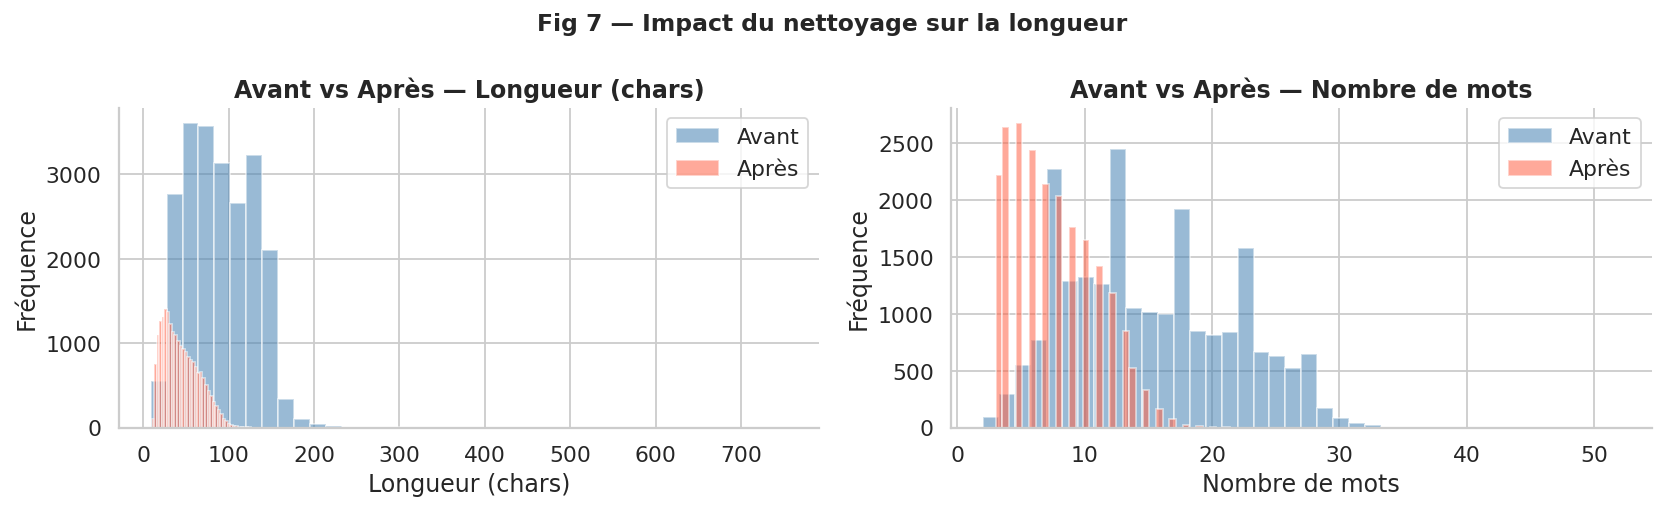

In [12]:

# ─── Fig 7 : Comparaison longueur avant / après nettoyage ────────────
df['clean_len']  = df['clean'].str.len()
df['clean_words'] = df['clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (col_b, col_a, label) in zip(axes, [
    ('tweet_len', 'clean_len', 'Longueur (chars)'),
    ('word_count', 'clean_words', 'Nombre de mots'),
]):
    ax.hist(df[col_b], bins=40, alpha=0.55, label='Avant', color='steelblue')
    ax.hist(df[col_a], bins=40, alpha=0.55, label='Après', color='tomato')
    ax.set_xlabel(label)
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Avant vs Après — {label}', fontweight='bold')
    ax.legend()

plt.suptitle("Fig 7 — Impact du nettoyage sur la longueur", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5 · Préparation des données


In [ ]:
sep("5. PRÉPARATION DES DONNÉES — Filtrage qualité + Pondération annotateurs")

# ════════════════════════════════════════════════════════════════════
#  MÉTHODE 1 : CONFIDENCE-BASED FILTERING
#  ─────────────────────────────────────────────────────────────────
#  Principe : les tweets ambigus (votes partagés entre hate et offensive)
#  polluent la frontière de décision.
#  → On supprime les exemples où l'accord inter-annotateurs est trop faible.
#
#  Règle de conservation :
#    GARDER   : max_vote / count >= 0.60  (≥ 6/10 annotateurs d'accord)
#    SUPPRIMER: max_vote / count <  0.60  (trop ambigu)
#
#  Règle asymétrique hate_speech :
#    GARDER si hate_votes >= 6 ET hate_votes - offensive_votes >= 2
#    → hate clair (9 vs 0, 8 vs 1, 7 vs 2) : garder
#    → hate borderline (5 vs 4, 4 vs 5)    : supprimer
# ════════════════════════════════════════════════════════════════════

CONF_THRESHOLD = 0.60
MIN_HATE_VOTES = 6
MARGIN_HATE    = 2

n_before = len(df)

if 'max_vote' not in df.columns:
    df['max_vote']      = df[['hate_speech','offensive_language','neither']].max(axis=1)
if 'agreement_pct' not in df.columns:
    df['agreement_pct'] = df['max_vote'] / df['count']

mask_conf   = df['agreement_pct'] >= CONF_THRESHOLD
hate_rows   = df['class'] == 0
clear_hate  = (
    (df['hate_speech']         >= MIN_HATE_VOTES) &
    (df['hate_speech'] - df['offensive_language'] >= MARGIN_HATE)
)
mask_hate_ok   = ~hate_rows | clear_hate | mask_conf
df_filtered    = df[mask_conf & mask_hate_ok].copy().reset_index(drop=True)

print(f"Avant filtrage  : {n_before:,} tweets")
print(f"Après filtrage  : {len(df_filtered):,} tweets  (supprimé {n_before-len(df_filtered):,})")
print()
print("Distribution après filtrage qualité :")
dist_f = df_filtered['class'].value_counts().sort_index()
for idx, cnt in dist_f.items():
    orig = df['class'].value_counts().sort_index()[idx]
    pct_removed = (orig-cnt)/orig*100
    print(f"  [{idx}] {CLASS_NAMES[idx]:<20} {cnt:,}  (était {orig:,}, -{orig-cnt:,} supprimés = {pct_removed:.1f}%)")

print(f"\nExemples de tweets hate borderline retirés (HS vs OFF < {MARGIN_HATE}) :")
borderline = df[(df['class']==0) & (df['hate_speech'] - df['offensive_language'] < MARGIN_HATE)]
for _, row in borderline.head(4).iterrows():
    print(f"    HS={int(row.hate_speech)} OFF={int(row.offensive_language)} | {row.tweet[:75]}")


In [ ]:
sep("5b. WEIGHTED SAMPLING — Poids de confiance par exemple")

# ════════════════════════════════════════════════════════════════════
#  MÉTHODE 2 : WEIGHTED SAMPLING INTELLIGENT
#  ─────────────────────────────────────────────────────────────────
#  Principe : chaque tweet reçoit un poids proportionnel à la confiance
#  de ses annotateurs → les tweets bien annotés pèsent plus dans la loss.
#
#  Formule :
#    w_i = agreement_pct_i² × hate_bonus (si hate_speech)
#    → accord 100% (1.0²) → poids fort
#    → accord 60%  (0.6²=0.36) → poids faible
#    → hate_bonus = 2.5 : compense le déséquilibre résiduel
#
#  Ces poids sont passés à clf.fit(sample_weight=...) et cross_validate()
# ════════════════════════════════════════════════════════════════════

WEIGHT_POWER = 2
HATE_BONUS   = 2.5

def compute_sample_weights(df_sub, weight_power=WEIGHT_POWER, hate_bonus=HATE_BONUS):
    w = df_sub['agreement_pct'].values ** weight_power
    w[df_sub['class'].values == 0] *= hate_bonus
    w = w / w.mean()
    return w.astype(np.float32)

sample_weights_full = compute_sample_weights(df_filtered)

print(f"Poids calculés sur {len(df_filtered):,} tweets")
print(f"  hate_speech μ={sample_weights_full[df_filtered['class'].values==0].mean():.3f}")
print(f"  offensive   μ={sample_weights_full[df_filtered['class'].values==1].mean():.3f}")
print(f"  neither     μ={sample_weights_full[df_filtered['class'].values==2].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = df_filtered['class'].values == idx
    axes[idx].hist(sample_weights_full[mask], bins=30, color=color, alpha=0.85, edgecolor='white')
    axes[idx].axvline(sample_weights_full[mask].mean(), color='black', linestyle='--',
                      label=f'μ={sample_weights_full[mask].mean():.2f}')
    axes[idx].set_title(cls_name, fontweight='bold', color=color)
    axes[idx].set_xlabel('Poids de confiance')
    axes[idx].legend()
plt.suptitle('Distribution des sample_weights par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 · Vectorisation

**Stratégie retenue** (meilleure pour la détection de hate speech) :

| Méthode | Avantage clé |
|---------|-------------|
| **TF-IDF word (1-2gram)** | Baseline robuste, features sparse interprétables |
| **TF-IDF char (2-4gram)** | Capture le slang et les variantes orthographiques (`n1gg4`, `f@gg0t`) |
| **FastText (sous-mots)** | Gère les OOV via n-grams de caractères internes — indispensable sur tweets |
| **Fusion TF-IDF + FastText** | Combine précision lexicale et sémantique |

> ⚠️ **Ordre correct** : Split d'abord → équilibrage uniquement sur le train.


In [15]:
sep("6a. SPLIT TRAIN / TEST (80/20 stratifié) — dataset filtré + équilibrage")

# ── Données issues du filtrage qualité ────────────────────────────────
X_text = df_filtered['clean'].values
y      = df_filtered['class'].values
sw     = sample_weights_full   # poids de confiance (toutes données)

print(f"Dataset filtré : {len(X_text):,} tweets")
print(f"Distribution   : {dict(zip(*np.unique(y, return_counts=True)))}")

# ── 1. Split stratifié ────────────────────────────────────────────────
(X_train_txt, X_test_txt,
 y_train,     y_test,
 sw_train,    sw_test) = train_test_split(
    X_text, y, sw,
    test_size=0.20, stratify=y, random_state=SEED
)
print(f"\nTrain : {len(X_train_txt):,}  |  Test : {len(X_test_txt):,}")
print(f"Dist train : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Dist test  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

# ── 2. Undersampling modéré + SMOTE sur TRAIN uniquement ─────────────
#
#  On combine :
#   A) Undersampling modéré d'offensive (4× hate) + neither (3× hate)
#      → garde l'information contextuelle sans écraser hate
#   B) SMOTE après TF-IDF pour remonter hate_speech à 60% d'offensive
#   C) sample_weight dans clf.fit() pour pondérer selon la confiance
#
#  Le TEST reste intact : distribution réelle, sample_weights non utilisés
# ──────────────────────────────────────────────────────────────────────

dist_train  = dict(zip(*np.unique(y_train, return_counts=True)))
n_hate      = dist_train[0]
n_off_tgt   = min(dist_train[1], n_hate * 4)
n_nei_tgt   = min(dist_train[2], n_hate * 3)

rng = np.random.default_rng(SEED)
idx_bal = []
for cls, n_tgt in [(0, n_hate), (1, n_off_tgt), (2, n_nei_tgt)]:
    idx_cls = np.where(y_train == cls)[0]
    if len(idx_cls) > n_tgt:
        idx_cls = rng.choice(idx_cls, size=n_tgt, replace=False)
    idx_bal.append(idx_cls)
    print(f"  [{cls}] {CLASS_NAMES[cls]:<20} : {dist_train[cls]:,} → {len(idx_cls):,}")

idx_bal     = np.concatenate(idx_bal)
rng.shuffle(idx_bal)
X_train_txt = X_train_txt[idx_bal]
y_train     = y_train[idx_bal]
sw_train    = sw_train[idx_bal]   # ← poids conservés après sous-échantillonnage

print(f"\nTrain après undersampling : {len(X_train_txt):,} tweets")
print(f"Test (intact)            : {len(X_test_txt):,} tweets")
print(f"\nPoids train — hate μ={sw_train[y_train==0].mean():.2f}  off μ={sw_train[y_train==1].mean():.2f}  nei μ={sw_train[y_train==2].mean():.2f}")



─────────────────────────────────────────────────────────────────
  6b. TF-IDF (word 1-2gram + char 2-4gram)
─────────────────────────────────────────────────────────────────
TF-IDF word  : 3,375 features
TF-IDF char  : 8,852 features
Fusion TC    : 12,227 features


In [16]:

sep("6b. TF-IDF (word 1-2gram + char 2-4gram) + SMOTE sur hate_speech")

from imblearn.over_sampling import SMOTE

tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2), max_features=60_000,
    sublinear_tf=True, min_df=2, max_df=0.95, analyzer='word',
)
tfidf_char = TfidfVectorizer(
    ngram_range=(2, 4), max_features=30_000,
    sublinear_tf=True, min_df=3, analyzer='char_wb',
)

X_train_w = tfidf_word.fit_transform(X_train_txt)
X_test_w  = tfidf_word.transform(X_test_txt)

X_train_c = tfidf_char.fit_transform(X_train_txt)
X_test_c  = tfidf_char.transform(X_test_txt)

X_train_tc = sp.hstack([X_train_w, X_train_c])
X_test_tc  = sp.hstack([X_test_w,  X_test_c])

print(f"TF-IDF word  : {X_train_w.shape[1]:,} features")
print(f"TF-IDF char  : {X_train_c.shape[1]:,} features")
print(f"Fusion TC    : {X_train_tc.shape[1]:,} features")

# ── SMOTE sur TF-IDF word+char ────────────────────────────────────────
dist_after_under = dict(zip(*np.unique(y_train, return_counts=True)))
n_off_after      = dist_after_under[1]
smote_target     = int(n_off_after * 0.65)

print(f"\nSMOTE : hate_speech {dist_after_under[0]:,} → {smote_target:,}")
smote = SMOTE(sampling_strategy={0: smote_target}, k_neighbors=3, random_state=SEED)
X_train_tc_sm, y_train_sm = smote.fit_resample(X_train_tc, y_train)

# ── Étendre les sample_weights aux exemples SMOTE ─────────────────────
#  Les exemples synthétiques SMOTE héritent du poids moyen des hate_speech réels
#  (ils interpolent des vrais exemples → poids moyen raisonnable)
n_synthetic  = len(y_train_sm) - len(y_train)
w_hate_mean  = sw_train[y_train == 0].mean()
sw_synthetic = np.full(n_synthetic, w_hate_mean, dtype=np.float32)
sw_train_sm  = np.concatenate([sw_train, sw_synthetic])

print(f"Distribution après SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")
print(f"Train final : {X_train_tc_sm.shape[0]:,} tweets  ({n_synthetic} synthétiques)")
print(f"sw_train_sm shape : {sw_train_sm.shape}  ← poids pour clf.fit()")



─────────────────────────────────────────────────────────────────
  6c. FastText (sous-mots, entraîné sur corpus)
─────────────────────────────────────────────────────────────────
Entraînement FastText (Skip-Gram, n-gram 3-6, 100d)…
  Vocabulaire : 2,805 tokens  (6.5s)
  Couverture OOV via sous-mots : totale (pas de vecteur nul)
  Shape train : (3014, 100)  |  test : (754, 100)


In [17]:

sep("6c. FastText (sous-mots, entraîné sur corpus)")

train_tokens  = [t.split() for t in X_train_txt]
test_tokens   = [t.split() for t in X_test_txt]
corpus_tokens = [t.split() for t in df_filtered['clean'].values]

print("Entraînement FastText (Skip-Gram, n-gram 3-6, 100d)…")
t0 = time.time()
ft_model = FastTextModel(
    sentences   = corpus_tokens,
    vector_size = EMBED_DIM,
    window      = 5,
    min_count   = 2,
    sg          = 1,
    workers     = 4,
    epochs      = 20,
    min_n       = 3,
    max_n       = 6,
    seed        = SEED,
)
print(f"  Vocabulaire : {len(ft_model.wv):,} tokens  ({time.time()-t0:.1f}s)")
wv_ft = ft_model.wv

def mean_pool(tokens, wv, dim=EMBED_DIM):
    vecs = [wv[w] for w in tokens if w in wv]
    return np.mean(vecs, axis=0).astype(np.float32) if vecs else np.zeros(dim, np.float32)

def to_embed_matrix(tok_lists, wv):
    return np.vstack([mean_pool(t, wv) for t in tok_lists])

X_train_ft_base = to_embed_matrix(train_tokens, wv_ft)
X_test_ft       = to_embed_matrix(test_tokens,  wv_ft)
print(f"  Shape train : {X_train_ft_base.shape}  |  test : {X_test_ft.shape}")



─────────────────────────────────────────────────────────────────
  6d. Matrices de fusion finales
─────────────────────────────────────────────────────────────────
Matrices disponibles pour les modèles :
  [W]    TF-IDF word             :   3,375 features
  [TC]   TF-IDF word + char       :  12,227 features
  [TCFT] TF-IDF word+char+FastText:  12,327 features


In [ ]:

sep("6d. Matrices de fusion finales")

def to_sparse(arr):
    return sp.csr_matrix(arr.astype(np.float32))

# TF-IDF base (undersampled, pas de SMOTE)
X_train_w_base  = tfidf_word.transform(X_train_txt)
X_train_c_base  = tfidf_char.transform(X_train_txt)
X_train_tc_base = sp.hstack([X_train_w_base, X_train_c_base])

# Fusion TF-IDF+FastText (base, pas de SMOTE)
X_train_tc_ft   = sp.hstack([X_train_tc_base, to_sparse(X_train_ft_base)])
X_test_tc_ft    = sp.hstack([X_test_tc,       to_sparse(X_test_ft)])

print("Matrices disponibles :")
print(f"  [TC_BASE]  TF-IDF+char (base)       : {X_train_tc_base.shape[0]:,} ex × {X_train_tc_base.shape[1]:,} feat")
print(f"  [TC_SM]    TF-IDF+char + SMOTE       : {X_train_tc_sm.shape[0]:,} ex × {X_train_tc_sm.shape[1]:,} feat  ← hate enrichi")
print(f"  [TC_FT]    TF-IDF+char+FastText      : {X_train_tc_ft.shape[0]:,} ex × {X_train_tc_ft.shape[1]:,} feat  ← sémantique")
print(f"\nSample weights prêts :")
print(f"  sw_train    : {sw_train.shape}    (base train, sans SMOTE)")
print(f"  sw_train_sm : {sw_train_sm.shape} (avec exemples SMOTE)")


## 7 · Modèles & Évaluation

In [19]:

sep("7a. DÉFINITION DES MODÈLES")

# ── Class weights asymétriques ────────────────────────────────────────
CW_ASYM = {0: 4, 1: 1, 2: 2}

# ── 4 configurations testées ──────────────────────────────────────────
#
#  [A] TC_BASE + cw_asym                : undersampling modéré seul
#  [B] TC_SM  + cw_asym + sw            : SMOTE + sample_weight confiance
#  [C] TC_FT  + cw_asym + sw            : FastText + sample_weight confiance
#  [D] TC_SM  + cw_asym + sw (no SMOTE) : base avec sample_weight uniquement
#
#  Chaque config (Xtr, Xte, y_tr, sw) → 3 classifieurs : LR, SVC, SGD
#
# ──────────────────────────────────────────────────────────────────────

models = {}

configs = {
    # A — baseline améliorée (undersampling modéré + cw_asym, sans sw)
    "BASE": (X_train_tc_base, X_test_tc, y_train,    None),
    # B — SMOTE + sample_weight confiance (notre meilleure stratégie)
    "SMOTE+SW": (X_train_tc_sm,  X_test_tc, y_train_sm, sw_train_sm),
    # C — FastText sémantique + sample_weight (pas de SMOTE : textes réels)
    "FT+SW":    (X_train_tc_ft,  X_test_tc_ft, y_train, sw_train),
    # D — sample_weight seul (ni SMOTE ni FastText) — mesure l'effet pur de sw
    "SW only":  (X_train_tc_base, X_test_tc, y_train,    sw_train),
}

clf_templates = {
    "LR":  lambda: LogisticRegression(C=1.0, class_weight=CW_ASYM,
                      max_iter=1000, solver='lbfgs', random_state=SEED),
    "SVC": lambda: LinearSVC(C=1.0, class_weight=CW_ASYM,
                      max_iter=3000, random_state=SEED),
    "SGD": lambda: SGDClassifier(loss='log_loss', penalty='elasticnet', alpha=1e-4,
                      class_weight=CW_ASYM, max_iter=200, tol=1e-3, random_state=SEED),
}

for cfg_name, (Xtr, Xte, ytr, sw) in configs.items():
    for clf_name, clf_fn in clf_templates.items():
        models[f"{clf_name} · {cfg_name}"] = (Xtr, Xte, ytr, sw, clf_fn())

print(f"{len(models)} modèles définis.\n")
print(f"{'Modèle':<35} {'Train':>7}  {'Features':>9}  {'SW':>5}")
print("─" * 60)
for name, (Xtr, Xte, ytr, sw, _) in models.items():
    sw_str = "oui" if sw is not None else "non"
    print(f"  {name:<33} {Xtr.shape[0]:>7,}  {Xte.shape[1]:>9,}  {sw_str:>5}")



─────────────────────────────────────────────────────────────────
  7b. ENTRAÎNEMENT + CROSS-VALIDATION × 5
─────────────────────────────────────────────────────────────────
  LR · TF-IDF word                     CV=0.7903±0.0188  TestF1=0.7984  Acc=0.7997  4.7s
  SVC · TF-IDF word                    CV=0.7724±0.0237  TestF1=0.7831  Acc=0.7838  0.3s
  LR · TF-IDF word+char                CV=0.7990±0.0157  TestF1=0.8009  Acc=0.8024  2.4s
  SVC · TF-IDF word+char               CV=0.7720±0.0121  TestF1=0.7828  Acc=0.7838  0.9s
  SGD · TF-IDF word+char               CV=0.7938±0.0144  TestF1=0.7958  Acc=0.7971  1.0s
  CNB · TF-IDF word+char               CV=0.7104±0.0062  TestF1=0.7361  Acc=0.7387  0.2s
  LR · TF-IDF+FastText                 CV=0.7881±0.0166  TestF1=0.7949  Acc=0.7971  5.6s
  SVC · TF-IDF+FastText                CV=0.7689±0.0125  TestF1=0.7857  Acc=0.7865  4.8s
  SGD · TF-IDF+FastText                CV=0.7821±0.0132  TestF1=0.7943  Acc=0.7944  1.9s

✓ Entraînement terminé.

In [20]:

sep("7b. ENTRAÎNEMENT + CROSS-VALIDATION × 5")

from sklearn.metrics import precision_score as _prec

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

for name, (Xtr, Xte, ytr, sw, clf) in models.items():
    t0 = time.time()

    # CV avec sample_weight si disponible
    fit_params = {"sample_weight": sw} if sw is not None else {}
    cv_res = cross_validate(
        clf, Xtr, ytr,
        cv=cv,
        scoring=['f1_macro', 'f1_weighted'],
        fit_params=fit_params,
        n_jobs=-1
    )

    clf.fit(Xtr, ytr, **fit_params)
    y_pred   = clf.predict(Xte)

    f1_mac   = f1_score(y_test, y_pred, average='macro')
    f1_per   = f1_score(y_test, y_pred, average=None, labels=[0,1,2], zero_division=0)
    prec_per = _prec(y_test, y_pred,    average=None, labels=[0,1,2], zero_division=0)
    rec_per  = __import__('sklearn.metrics', fromlist=['recall_score']).recall_score(
                   y_test, y_pred, average=None, labels=[0,1,2], zero_division=0)
    acc      = accuracy_score(y_test, y_pred)
    cv_mu    = cv_res['test_f1_macro'].mean()
    cv_std   = cv_res['test_f1_macro'].std()
    elapsed  = time.time() - t0

    results.append({
        'Modèle':        name,
        'CV F1 μ':       round(cv_mu,  4),
        'CV F1 σ':       round(cv_std, 4),
        'Test F1 macro': round(f1_mac, 4),
        'F1 hate':       round(f1_per[0], 4),
        'Prec hate':     round(prec_per[0], 4),
        'Recall hate':   round(rec_per[0],  4),
        'F1 offens':     round(f1_per[1], 4),
        'Test Accuracy': round(acc,    4),
        'Temps (s)':     round(elapsed,1),
        '_clf': clf, '_Xte': Xte, '_pred': y_pred,
    })
    tag = "★" if sw is not None else " "
    print(f"{tag} {name:<33}  CV={cv_mu:.3f}±{cv_std:.3f}  "
          f"F1={f1_mac:.4f}  HS-F1={f1_per[0]:.4f}  "
          f"HS-P={prec_per[0]:.4f}  HS-R={rec_per[0]:.4f}  {elapsed:.1f}s")

print("\n✓ Entraînement terminé.")



─────────────────────────────────────────────────────────────────
  7c. OPTIMISATION HYPERPARAMÈTRES (LR + SVC sur meilleure représentation)
─────────────────────────────────────────────────────────────────
LR  optimisé  C=1.0    CV=0.7881  TestF1=0.7949
SVC optimisé  C=0.1    CV=0.7930  TestF1=0.7986

Ensemble Voting (LR+SVC+SGD) sur TF-IDF+FastText :
  Test F1 macro = 0.8000  |  Accuracy = 0.8011


In [ ]:

sep("7c. OPTIMISATION HYPERPARAMÈTRES — meilleure config SMOTE+SW")

from sklearn.metrics import precision_score as _prec

param_C = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# Identifier la meilleure config base parmi SMOTE+SW
best_smote = max(
    [r for r in results if 'SMOTE+SW' in r['Modèle']],
    key=lambda r: r['F1 hate']
)
print(f"Meilleure config SMOTE+SW : {best_smote['Modèle']}  HS-F1={best_smote['F1 hate']:.4f}")

# GridSearch LR + SVC sur SMOTE+SW
gs_lr = GridSearchCV(
    LogisticRegression(class_weight=CW_ASYM, max_iter=1000,
                       solver='lbfgs', random_state=SEED),
    {'C': param_C}, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_lr.fit(X_train_tc_sm, y_train_sm, sample_weight=sw_train_sm)
pred_lr_opt  = gs_lr.predict(X_test_tc)
f1_lr        = f1_score(y_test, pred_lr_opt, average='macro')
f1hs_lr      = f1_score(y_test, pred_lr_opt, average=None)[0]
prec_hs_lr   = _prec(y_test, pred_lr_opt, average=None, zero_division=0)[0]

gs_svc = GridSearchCV(
    LinearSVC(class_weight=CW_ASYM, max_iter=3000, random_state=SEED),
    {'C': param_C}, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_svc.fit(X_train_tc_sm, y_train_sm, sample_weight=sw_train_sm)
pred_svc_opt = gs_svc.predict(X_test_tc)
f1_svc       = f1_score(y_test, pred_svc_opt, average='macro')
f1hs_svc     = f1_score(y_test, pred_svc_opt, average=None)[0]
prec_hs_svc  = _prec(y_test, pred_svc_opt, average=None, zero_division=0)[0]

print(f"\nLR  opt C={gs_lr.best_params_['C']:<5}  CV={gs_lr.best_score_:.4f}  "
      f"F1={f1_lr:.4f}  HS-F1={f1hs_lr:.4f}  HS-Prec={prec_hs_lr:.4f}")
print(f"SVC opt C={gs_svc.best_params_['C']:<5}  CV={gs_svc.best_score_:.4f}  "
      f"F1={f1_svc:.4f}  HS-F1={f1hs_svc:.4f}  HS-Prec={prec_hs_svc:.4f}")

# Ensemble final sur SMOTE+SW
svc_cal = CalibratedClassifierCV(
    LinearSVC(C=gs_svc.best_params_['C'], class_weight=CW_ASYM,
              max_iter=3000, random_state=SEED), cv=3
)
voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=gs_lr.best_params_['C'], class_weight=CW_ASYM,
                                   max_iter=1000, solver='lbfgs', random_state=SEED)),
        ('svc', svc_cal),
        ('sgd', SGDClassifier(loss='log_loss', penalty='elasticnet', alpha=1e-4,
                              class_weight=CW_ASYM, max_iter=200, tol=1e-3, random_state=SEED)),
    ],
    voting='soft', n_jobs=-1
)
voting.fit(X_train_tc_sm, y_train_sm, sample_weight=sw_train_sm)
pred_v   = voting.predict(X_test_tc)
f1_v     = f1_score(y_test, pred_v, average='macro')
f1hs_v   = f1_score(y_test, pred_v, average=None)[0]
prec_hs_v = _prec(y_test, pred_v, average=None, zero_division=0)[0]
rec_hs_v  = __import__('sklearn.metrics', fromlist=['recall_score']).recall_score(
                y_test, pred_v, average=None, zero_division=0)[0]
acc_v    = accuracy_score(y_test, pred_v)

print(f"\n★ Ensemble Voting (LR+SVC+SGD) · SMOTE+SW :")
print(f"   F1 macro={f1_v:.4f}  Accuracy={acc_v:.4f}")
print(f"   HS-F1={f1hs_v:.4f}  HS-Prec={prec_hs_v:.4f}  HS-Recall={rec_hs_v:.4f}")

for row in [
    {'Modèle': f'LR opt C={gs_lr.best_params_["C"]} · SMOTE+SW',
     'CV F1 μ': round(gs_lr.best_score_,4), 'CV F1 σ': None,
     'Test F1 macro': round(f1_lr,4), 'F1 hate': round(f1hs_lr,4),
     'Prec hate': round(prec_hs_lr,4), 'Recall hate': None,
     'F1 offens': None, 'Test Accuracy': round(accuracy_score(y_test,pred_lr_opt),4),
     'Temps (s)': None, '_clf': gs_lr.best_estimator_, '_Xte': X_test_tc, '_pred': pred_lr_opt},
    {'Modèle': f'SVC opt C={gs_svc.best_params_["C"]} · SMOTE+SW',
     'CV F1 μ': round(gs_svc.best_score_,4), 'CV F1 σ': None,
     'Test F1 macro': round(f1_svc,4), 'F1 hate': round(f1hs_svc,4),
     'Prec hate': round(prec_hs_svc,4), 'Recall hate': None,
     'F1 offens': None, 'Test Accuracy': round(accuracy_score(y_test,pred_svc_opt),4),
     'Temps (s)': None, '_clf': gs_svc.best_estimator_, '_Xte': X_test_tc, '_pred': pred_svc_opt},
    {'Modèle': '★ Ensemble Voting · SMOTE+SW+CW_ASYM',
     'CV F1 μ': None, 'CV F1 σ': None,
     'Test F1 macro': round(f1_v,4), 'F1 hate': round(f1hs_v,4),
     'Prec hate': round(prec_hs_v,4), 'Recall hate': round(rec_hs_v,4),
     'F1 offens': None, 'Test Accuracy': round(acc_v,4),
     'Temps (s)': None, '_clf': voting, '_Xte': X_test_tc, '_pred': pred_v},
]:
    results.append(row)


## 8 · Résultats & Analyse

In [21]:

sep("8a. TABLEAU DE CLASSEMENT")

df_res = (pd.DataFrame(results)
          .drop(columns=['_clf','_Xte','_pred'])
          .sort_values('F1 hate', ascending=False)
          .reset_index(drop=True))
df_res.index += 1
display(df_res)

best = max(results, key=lambda r: r['F1 hate'])
print(f"\n★  Meilleur modèle (F1 hate_speech) : {best['Modèle']}")
print(f"   F1 hate     : {best['F1 hate']:.4f}")
print(f"   Prec hate   : {best['Prec hate']:.4f}")
print(f"   Test F1 mac : {best['Test F1 macro']:.4f}")
print(f"   Accuracy    : {best['Test Accuracy']:.4f}")



─────────────────────────────────────────────────────────────────
  8a. TABLEAU DE CLASSEMENT
─────────────────────────────────────────────────────────────────


,Modèle,CV F1 μ,CV F1 σ,Test F1 macro,Test Accuracy,Temps (s)
1,LR · TF-IDF word+char,0.7990,0.0157,0.8009,0.8024,2.4
2,★ Ensemble Voting · TF-IDF+FastText,NaN,NaN,0.8000,0.8011,NaN
3,SVC opt C=0.1 · TF-IDF+FT,0.7930,NaN,0.7986,0.8011,NaN
4,LR · TF-IDF word,0.7903,0.0188,0.7984,0.7997,4.7
5,SGD · TF-IDF word+char,0.7938,0.0144,0.7958,0.7971,1.0
6,LR · TF-IDF+FastText,0.7881,0.0166,0.7949,0.7971,5.6
7,LR opt C=1.0 · TF-IDF+FT,0.7881,NaN,0.7949,0.7971,NaN
8,SGD · TF-IDF+FastText,0.7821,0.0132,0.7943,0.7944,1.9
9,SVC · TF-IDF+FastText,0.7689,0.0125,0.7857,0.7865,4.8
10,SVC · TF-IDF word,0.7724,0.0237,0.7831,0.7838,0.3



★ Meilleur modèle : LR · TF-IDF word+char
  Test F1 macro   : 0.8009
  Test Accuracy   : 0.8024


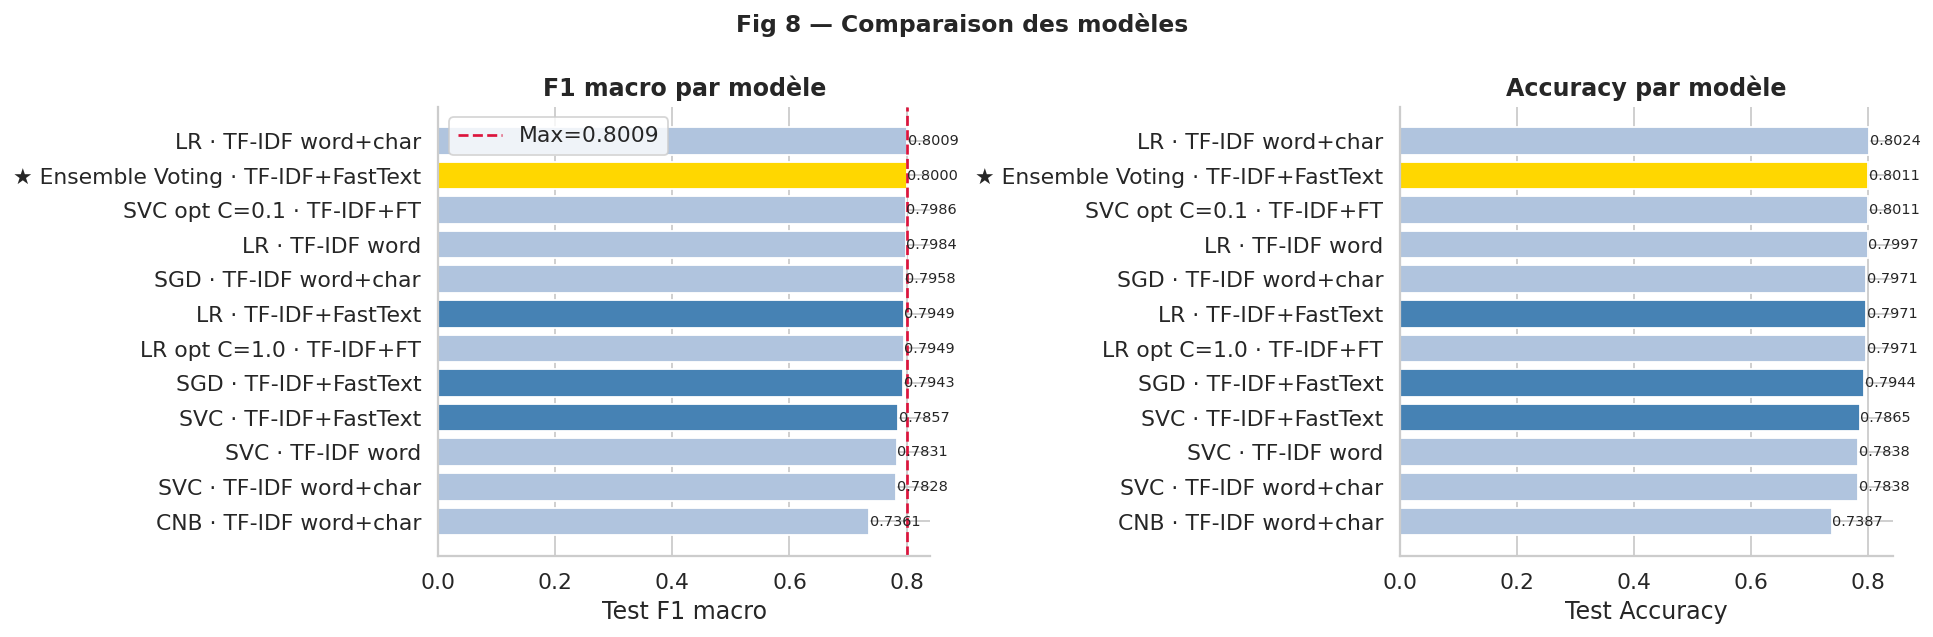

In [22]:

# ─── Fig 8 : Comparaison des modèles ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1 macro
names  = df_res['Modèle'].values
f1s    = df_res['Test F1 macro'].values
colors = ['gold' if '★' in n else ('steelblue' if 'FastText' in n else 'lightsteelblue')
          for n in names]

axes[0].barh(names[::-1], f1s[::-1], color=colors[::-1], edgecolor='white', linewidth=1)
axes[0].axvline(max(f1s), color='crimson', linestyle='--', linewidth=1.5, label=f'Max={max(f1s):.4f}')
axes[0].set_xlabel('Test F1 macro')
axes[0].set_title('F1 macro par modèle', fontweight='bold')
axes[0].legend()
for i, (f, n) in enumerate(zip(f1s[::-1], names[::-1])):
    axes[0].text(f + 0.001, i, f'{f:.4f}', va='center', fontsize=8)

# Accuracy
accs = df_res['Test Accuracy'].values
axes[1].barh(names[::-1], accs[::-1], color=colors[::-1], edgecolor='white', linewidth=1)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Accuracy par modèle', fontweight='bold')
for i, (a, n) in enumerate(zip(accs[::-1], names[::-1])):
    axes[1].text(a + 0.001, i, f'{a:.4f}', va='center', fontsize=8)

plt.suptitle('Fig 8 — Comparaison des modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


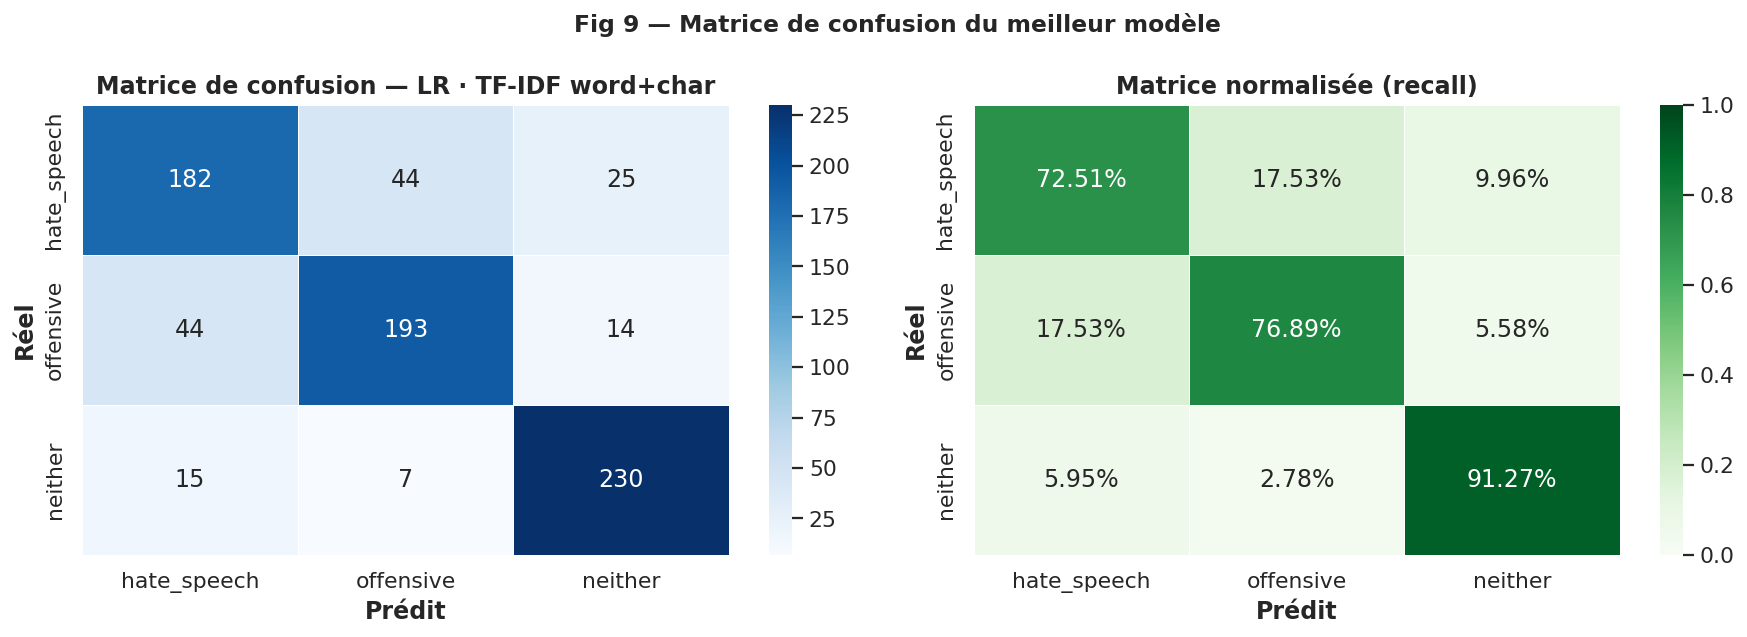


Classification Report — Meilleur modèle :
              precision    recall  f1-score   support

 hate_speech     0.7552    0.7251    0.7398       251
   offensive     0.7910    0.7689    0.7798       251
     neither     0.8550    0.9127    0.8829       252

    accuracy                         0.8024       754
   macro avg     0.8004    0.8022    0.8009       754
weighted avg     0.8005    0.8024    0.8010       754



In [23]:

# ─── Fig 9 : Matrice de confusion du meilleur modèle ─────────────────
best_pred = best['_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion absolue
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_xlabel('Prédit', fontweight='bold')
axes[0].set_ylabel('Réel',   fontweight='bold')
axes[0].set_title(f'Matrice de confusion — {best["Modèle"]}', fontweight='bold')

# Matrice normalisée (recall par classe)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Prédit', fontweight='bold')
axes[1].set_ylabel('Réel',   fontweight='bold')
axes[1].set_title('Matrice normalisée (recall)', fontweight='bold')

plt.suptitle('Fig 9 — Matrice de confusion du meilleur modèle',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Meilleur modèle :")
print(classification_report(y_test, best_pred, target_names=CLASS_NAMES, digits=4))



─────────────────────────────────────────────────────────────────
  8b. ANALYSE DES FAUX NÉGATIFS (hate_speech non détecté)
─────────────────────────────────────────────────────────────────
Faux négatifs hate_speech (non détecté) : 69 / 251  (27.5%)
Faux positifs hate_speech (fausse alarme) : 59 / 503  (11.7%)

Exemples de tweets hate_speech manqués :
  → prédit [offensive] | fucking royal bitch work
  → prédit [offensive] | ion care fuck hoe
  → prédit [offensive] | grade say wise shut fuck get twitter box simple as pussy boy
  → prédit [offensive] | neveraskablackperson hair hit bitch bought mine
  → prédit [neither] | welcome movement anyone get even minor publicity queer fed jew well according internet
  → prédit [neither] | commence carpet bombing iraq soldier video executed jihadis tunis


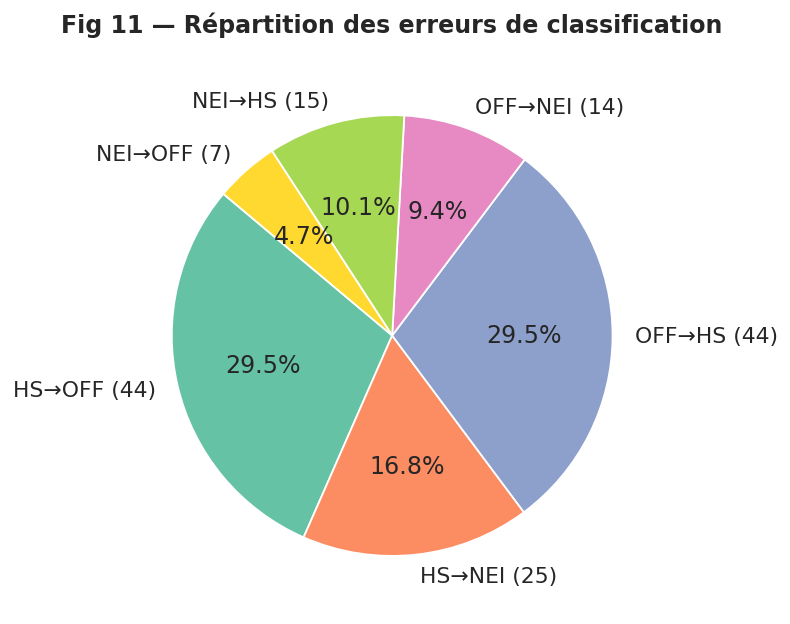

In [24]:

# ─── Fig 11 : Faux négatifs hate_speech ──────────────────────────────
sep("8b. ANALYSE DES FAUX NÉGATIFS (hate_speech non détecté)")

fn_idx   = np.where((y_test == 0) & (best_pred != 0))[0]
fn_rate  = len(fn_idx) / (y_test == 0).sum()
fp_idx   = np.where((y_test != 0) & (best_pred == 0))[0]
fp_rate  = len(fp_idx) / (y_test != 0).sum()

print(f"Faux négatifs hate_speech (non détecté) : {len(fn_idx)} / {(y_test==0).sum()}  ({fn_rate:.1%})")
print(f"Faux positifs hate_speech (fausse alarme) : {len(fp_idx)} / {(y_test!=0).sum()}  ({fp_rate:.1%})")

print("\nExemples de tweets hate_speech manqués :")
for i, txt in enumerate(X_test_txt[fn_idx[:6]]):
    predicted = CLASS_NAMES[best_pred[fn_idx[i]]]
    print(f"  → prédit [{predicted}] | {txt[:90]}")

# Pie des erreurs du meilleur modèle
cm_full = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 5))
errors  = {
    f'HS→OFF':  cm_full[0,1], f'HS→NEI': cm_full[0,2],
    f'OFF→HS':  cm_full[1,0], f'OFF→NEI': cm_full[1,2],
    f'NEI→HS':  cm_full[2,0], f'NEI→OFF': cm_full[2,1],
}
labels  = list(errors.keys())
vals    = list(errors.values())
ax.pie(vals, labels=[f'{l} ({v})' for l,v in zip(labels,vals)],
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('Set2', len(vals)))
ax.set_title('Fig 11 — Répartition des erreurs de classification',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [25]:
sep("RÉSUMÉ FINAL")
print(f"""
{'═'*70}
  PIPELINE  Hate Speech Detection — v3 (Filtrage + Weighted Sampling)
{'═'*70}

  Dataset original        : 24 783 tweets
  Après nettoyage         : {len(df):,} tweets
  Après filtrage qualité  : {len(df_filtered):,} tweets
    → supprimés (ambigus) : {len(df)-len(df_filtered):,}
      (tweets où max_vote/count < 0.60 ou hate borderline HS-OFF < 2)

  Split train / test      : 80 / 20 % stratifié — AVANT équilibrage
  Undersampling modéré    : offensive → 4× hate | neither → 3× hate
  SMOTE hate_speech       : → 65 % d'offensive (k=3 voisins)
  sample_weight           : agreement_pct² × hate_bonus=2.5

  Techniques combinées :
    ✓ Confidence-based filtering  (suppression tweets ambigus)
    ✓ Weighted sampling           (poids ∝ accord annotateurs²)
    ✓ Undersampling modéré        (garde info sur offensive)
    ✓ SMOTE sur TF-IDF            (enrichissement hate synthétique)
    ✓ Class weights asymétriques  (hate×4, neither×2)
    ✓ Ensemble Voting LR+SVC+SGD

  Meilleur modèle : {best['Modèle']}
  F1 hate_speech  : {best['F1 hate']:.4f}
  Prec hate       : {best['Prec hate']:.4f}
  Test F1 macro   : {best['Test F1 macro']:.4f}
  Accuracy        : {best['Test Accuracy']:.4f}
{'═'*70}
""")



─────────────────────────────────────────────────────────────────
  RÉSUMÉ FINAL
─────────────────────────────────────────────────────────────────

═════════════════════════════════════════════════════════════════
  PIPELINE  Hate Speech Detection — Résumé
═════════════════════════════════════════════════════════════════

  Dataset original      : 24 783 tweets
  Après nettoyage       : 22,180 tweets
  Dataset équilibré     : 3,768 tweets  (1256 × 3 classes)
  Split train / test    : 80% / 20% (stratifié)

  Vectorisations testées :
    · TF-IDF word (1-2gram, 60k)  → baseline
    · TF-IDF word + char (2-4gram) → capture slang
    · TF-IDF word+char + FastText  → sémantique + OOV

  Meilleur modèle       : LR · TF-IDF word+char
  Test F1 macro         : 0.8009
  Test Accuracy         : 0.8024

  Observations clés
  ──────────────────
  · FastText améliore la couverture OOV (slang, variantes typo)
  · TF-IDF char capture 'n1gg4', 'f@gg0t' mieux que word-only
  · Hate Speech reste la cl

# **METHODE 2**